# **Phase 4: Predictive Modelling & Policy Intelligence**

**10Alytics Hackathon 2025**

---

This notebook covers three modelling tracks:

| Track | Model | Goal |
|-------|-------|------|
| 4A | Prophet (Time Series) | Forecast GDP Growth Rate per country |
| 4B | XGBoost Classifier | Predict fiscal risk (high/low deficit) |
| 4C | K-Means Clustering | Segment countries by fiscal health profile |

All models feed into a final **Policy Recommendation Framework**.

## **Setup & Data Loading**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
import joblib

# Plotting style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load panel data
# Update path if running from project root
FILE_PATH = '../data/processed/10Alytics_Fiscal_Panel_Data.csv'
df = pd.read_csv(FILE_PATH)

print(f'Dataset shape: {df.shape}')
print(f'Countries: {df["Country"].nunique()}')
print(f'Year range: {df["Year"].min()} – {df["Year"].max()}')
df.head()

Dataset shape: (6159, 32)
Countries: 14
Year range: 1960.0 – 2025.0


,Country,Country_Code,Time,Year,Frequency,Currency,Budget_Deficit_Surplus,Capital_Expenditure,Consumer_Price_Index_CPI,Defence_Expenditure,...,Inflation_Rate_,Interest_Rate,Labour_Force,Nominal_GDP,Population,Real_GDP,Revenue,Tax_Revenue,Unemployment_Rate,Value_Added_Tax_VAT
0,Algeria,DZA,1977-01-01,1977.0,Yearly,USD,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Algeria,DZA,1978-01-01,1978.0,Yearly,USD,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Algeria,DZA,1979-01-01,1979.0,Yearly,USD,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Algeria,DZA,1980-01-01,1980.0,Yearly,USD,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Algeria,DZA,1981-01-01,1981.0,Yearly,USD,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## **Track 4A — GDP Growth Rate Forecasting (Prophet)**

We use **Facebook Prophet** to forecast `GDP_Growth_Rate` for each of the top 5 countries.

Prophet handles:
- Missing/irregular time series
- Seasonality and trend changepoints
- Uncertainty intervals out of the box

In [2]:
try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
except ImportError:
    print('Prophet not installed. Run: pip install prophet')
    PROPHET_AVAILABLE = False

In [3]:
# --- 4A.1 Prepare time-series data per country ---

TOP_COUNTRIES = ['Nigeria', 'South Africa', 'Ghana', 'Egypt', 'Kenya']
FORECAST_YEARS = 5  # Forecast 5 years ahead

def prepare_prophet_df(df, country, target_col='GDP_Growth_Rate'):
    """Prepare a single-country time series in Prophet format (ds, y)."""
    country_df = (
        df[df['Country'] == country][['Year', target_col]]
        .dropna(subset=[target_col])
        .drop_duplicates(subset='Year')
        .sort_values('Year')
        .rename(columns={'Year': 'ds', target_col: 'y'})
    )
    # Prophet requires datetime
    country_df['ds'] = pd.to_datetime(country_df['ds'], format='%Y')
    return country_df

# Preview one country
sample = prepare_prophet_df(df, 'Nigeria')
print(f'Nigeria GDP Growth data points: {len(sample)}')
print(sample.tail())

Nigeria GDP Growth data points: 43
             ds     y
3596 2020-01-01  1.87
3613 2021-01-01  0.51
3630 2022-01-01  3.11
3647 2023-01-01  2.31
3664 2024-01-01  2.98


19:07:32 - cmdstanpy - INFO - Chain [1] start processing
19:07:32 - cmdstanpy - INFO - Chain [1] done processing
19:07:32 - cmdstanpy - INFO - Chain [1] start processing
19:07:32 - cmdstanpy - INFO - Chain [1] done processing
19:07:33 - cmdstanpy - INFO - Chain [1] start processing
19:07:33 - cmdstanpy - INFO - Chain [1] done processing
19:07:33 - cmdstanpy - INFO - Chain [1] start processing
19:07:33 - cmdstanpy - INFO - Chain [1] done processing
19:07:33 - cmdstanpy - INFO - Chain [1] start processing
19:07:33 - cmdstanpy - INFO - Chain [1] done processing


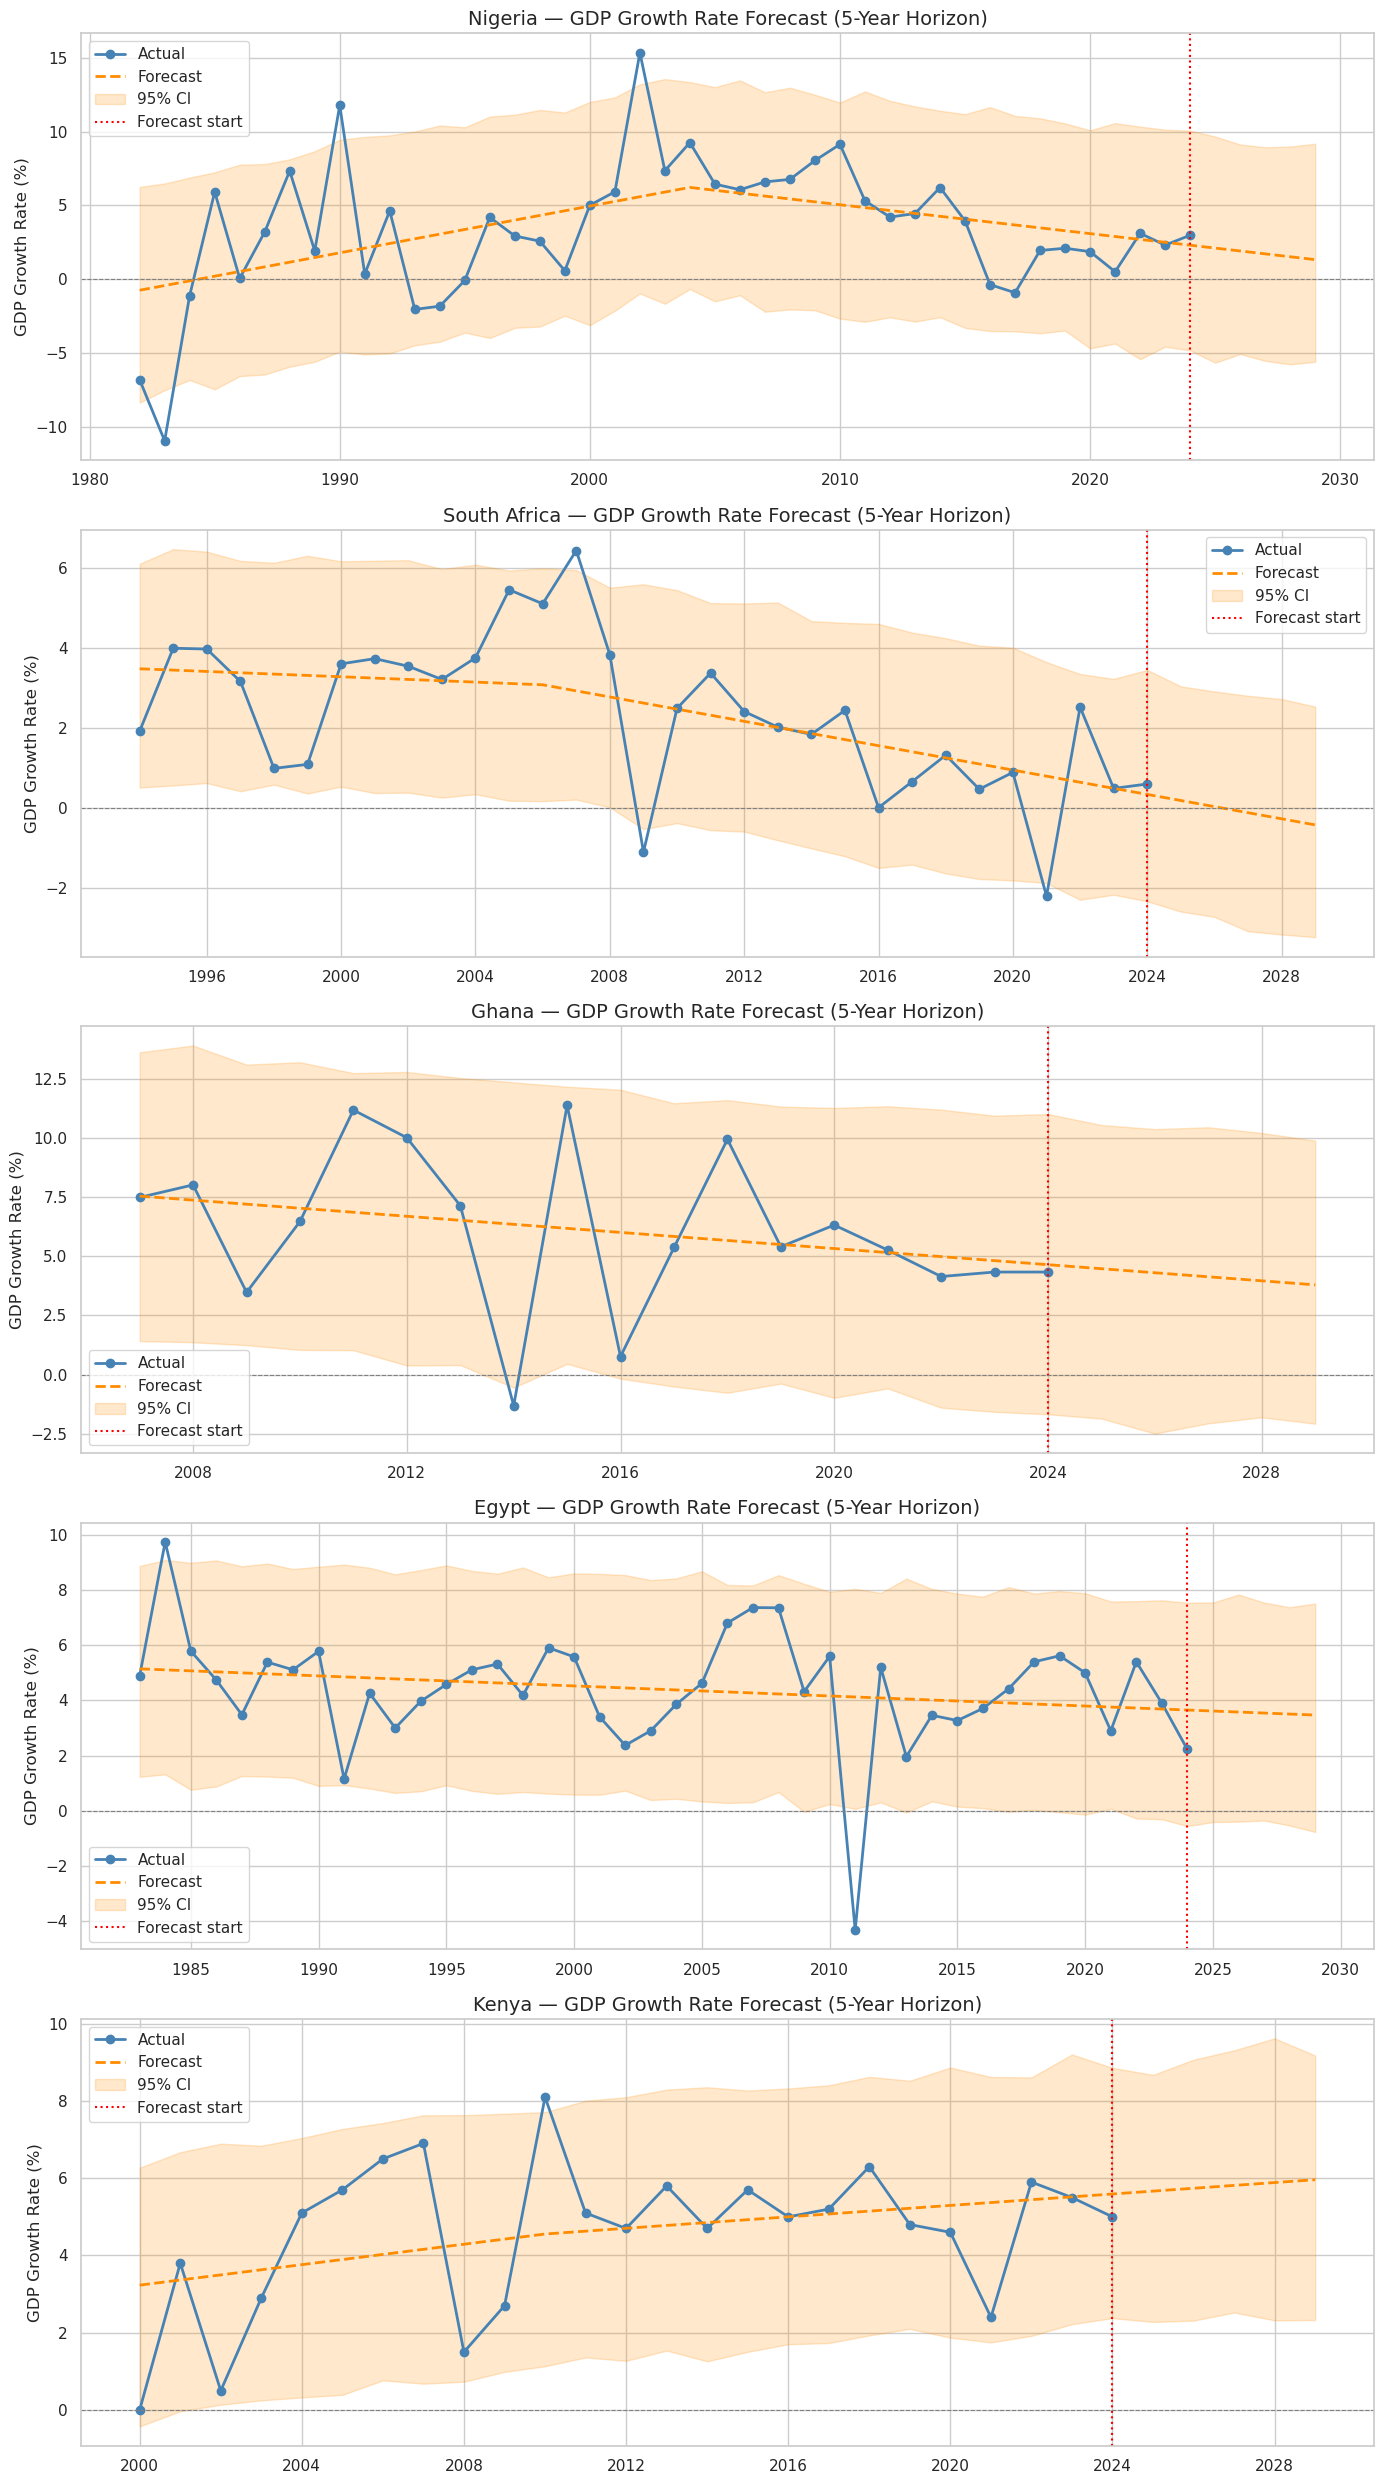


✅ Forecast chart saved to outputs/figures/gdp_growth_forecast.png


In [4]:
# --- 4A.2 Train Prophet and Forecast per Country ---

if PROPHET_AVAILABLE:
    fig, axes = plt.subplots(len(TOP_COUNTRIES), 1, figsize=(14, 5 * len(TOP_COUNTRIES)))
    forecast_results = {}

    for i, country in enumerate(TOP_COUNTRIES):
        prophet_df = prepare_prophet_df(df, country)

        if len(prophet_df) < 5:
            print(f'Skipping {country}: insufficient data ({len(prophet_df)} rows)')
            continue

        # Train model
        model = Prophet(
            yearly_seasonality=False,
            weekly_seasonality=False,
            daily_seasonality=False,
            changepoint_prior_scale=0.3,
            interval_width=0.95
        )
        model.fit(prophet_df)

        # Forecast
        future = model.make_future_dataframe(periods=FORECAST_YEARS, freq='YS')
        forecast = model.predict(future)
        forecast_results[country] = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

        # Plot
        ax = axes[i]
        ax.plot(prophet_df['ds'], prophet_df['y'], 'o-', color='steelblue', label='Actual', linewidth=2)
        ax.plot(forecast['ds'], forecast['yhat'], '--', color='darkorange', label='Forecast', linewidth=2)
        ax.fill_between(
            forecast['ds'],
            forecast['yhat_lower'],
            forecast['yhat_upper'],
            alpha=0.2, color='darkorange', label='95% CI'
        )
        ax.axvline(pd.Timestamp(prophet_df['ds'].max()), color='red', linestyle=':', label='Forecast start')
        ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
        ax.set_title(f'{country} — GDP Growth Rate Forecast ({FORECAST_YEARS}-Year Horizon)', fontsize=14)
        ax.set_ylabel('GDP Growth Rate (%)')
        ax.legend()
        ax.grid(True)

    plt.tight_layout()
    plt.savefig('../outputs/figures/gdp_growth_forecast.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('\n✅ Forecast chart saved to outputs/figures/gdp_growth_forecast.png')

In [5]:
# --- 4A.3 Print Forecast Summary Table ---

if PROPHET_AVAILABLE and forecast_results:
    print('\n=== GDP Growth Rate Forecasts (Next 5 Years) ===')
    for country, forecast in forecast_results.items():
        future_only = forecast[forecast['ds'] > pd.Timestamp(int(df['Year'].max()), 12, 31)].copy()
        future_only['Year'] = future_only['ds'].dt.year
        future_only['Forecast (%)'] = future_only['yhat'].round(2)
        future_only['Lower CI'] = future_only['yhat_lower'].round(2)
        future_only['Upper CI'] = future_only['yhat_upper'].round(2)
        print(f'\n{country}:')
        print(future_only[['Year', 'Forecast (%)', 'Lower CI', 'Upper CI']].to_string(index=False))


=== GDP Growth Rate Forecasts (Next 5 Years) ===

Nigeria:
 Year  Forecast (%)  Lower CI  Upper CI
 2026          1.92     -5.06      9.12
 2027          1.72     -5.52      8.93
 2028          1.52     -5.75      8.98
 2029          1.33     -5.59      9.17

South Africa:
 Year  Forecast (%)  Lower CI  Upper CI
 2026          0.04     -2.72      2.91
 2027         -0.12     -3.08      2.80
 2028         -0.27     -3.16      2.72
 2029         -0.42     -3.23      2.53

Ghana:
 Year  Forecast (%)  Lower CI  Upper CI
 2026          4.31     -2.50     10.39
 2027          4.14     -2.07     10.47
 2028          3.97     -1.81     10.23
 2029          3.80     -2.08      9.90

Egypt:
 Year  Forecast (%)  Lower CI  Upper CI
 2026          3.58     -0.40      7.84
 2027          3.54     -0.36      7.55
 2028          3.51     -0.54      7.38
 2029          3.47     -0.77      7.51

Kenya:
 Year  Forecast (%)  Lower CI  Upper CI
 2026          5.74      2.31      9.07
 2027          5.81  

## **Track 4B — Fiscal Risk Classification (XGBoost)**

We define **fiscal risk** as a binary label:
- `1` (High Risk): `Budget_Deficit_Surplus < 0` AND `Government_Debt > median`
- `0` (Low Risk): otherwise

Then we train an **XGBoost classifier** to predict risk from macroeconomic features.

In [6]:
# --- 4B.1 Define Fiscal Risk Label ---

FEATURES = [
    'Revenue', 'Expenditure', 'GDP_Growth_Rate',
    'Inflation_Rate_', 'Unemployment_Rate',
    'Tax_Revenue', 'Capital_Expenditure', 'Health_Expenditure'
]

TARGET = 'Fiscal_Risk'

# Filter only columns that actually exist in the dataset
available_features = [f for f in FEATURES if f in df.columns]
print(f'Using {len(available_features)} features: {available_features}')

# Create label
debt_median = df['Government_Debt'].median()
df[TARGET] = (
    (df['Budget_Deficit_Surplus'] < 0) &
    (df['Government_Debt'] > debt_median)
).astype(int)

print(f'\nFiscal Risk Label Distribution:')
print(df[TARGET].value_counts())
print(f'High Risk Proportion: {df[TARGET].mean():.1%}')

Using 8 features: ['Revenue', 'Expenditure', 'GDP_Growth_Rate', 'Inflation_Rate_', 'Unemployment_Rate', 'Tax_Revenue', 'Capital_Expenditure', 'Health_Expenditure']

Fiscal Risk Label Distribution:
Fiscal_Risk
0    5787
1     372
Name: count, dtype: int64
High Risk Proportion: 6.0%


In [8]:
# --- 4B.2 Prepare ML Dataset ---

# Impute missing values with column median instead of dropping rows
ml_df = df[available_features + [TARGET]].copy()
ml_df[available_features] = ml_df[available_features].fillna(ml_df[available_features].median())
ml_df = ml_df.dropna(subset=[TARGET])  # Only drop rows where target itself is missing

print(f'Clean ML dataset: {ml_df.shape[0]} rows, {ml_df.shape[1]-1} features')

X = ml_df[available_features]
y = ml_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

Clean ML dataset: 6159 rows, 8 features
Train: 4927 | Test: 1232


In [9]:
# --- 4B.3 Train XGBoost Classifier ---

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_test_scaled, y_test)],
    verbose=False
)

# Cross-validation
cv_scores = cross_val_score(xgb_model, X_train_scaled, y_train, cv=5, scoring='f1')
print(f'5-Fold CV F1 Score: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

# Test evaluation
y_pred = xgb_model.predict(X_test_scaled)
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Low Risk', 'High Risk']))

5-Fold CV F1 Score: 0.733 ± 0.024

Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.98      0.98      0.98      1158
   High Risk       0.72      0.70      0.71        74

    accuracy                           0.97      1232
   macro avg       0.85      0.84      0.85      1232
weighted avg       0.97      0.97      0.97      1232



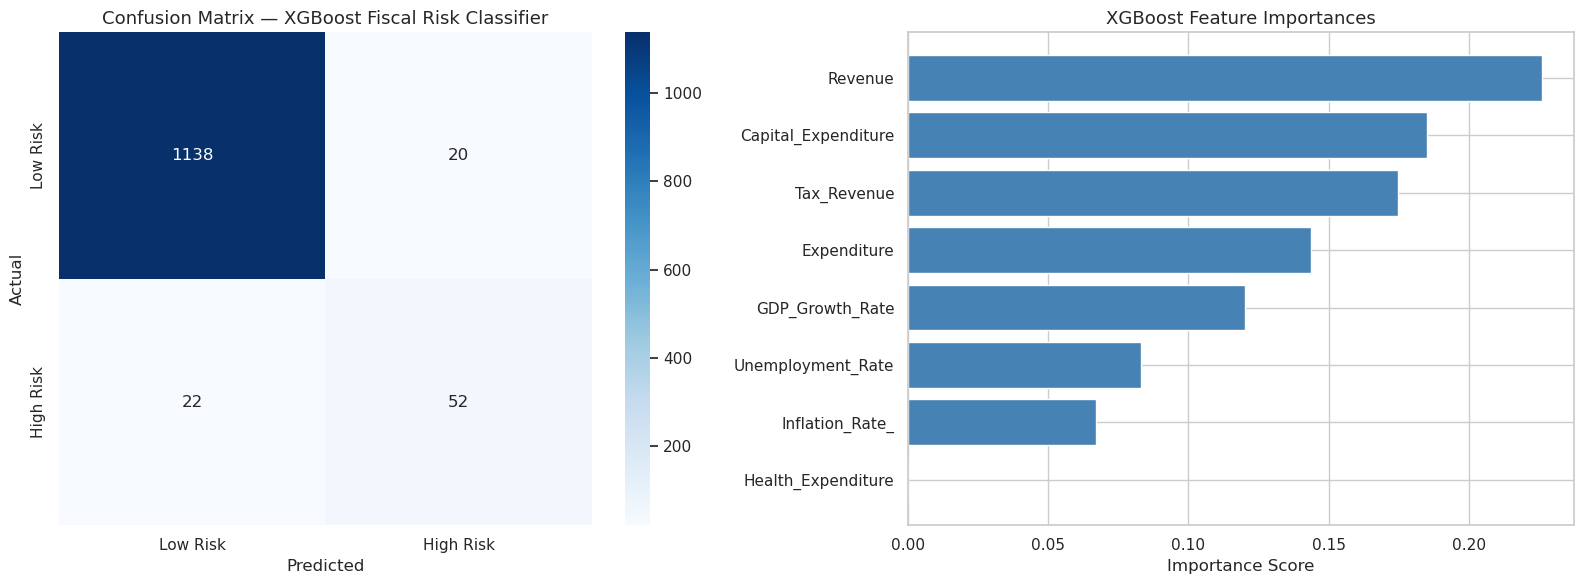


✅ Model saved to models/xgboost_fiscal_risk_v1.pkl


In [10]:
# --- 4B.4 Confusion Matrix & Feature Importance ---

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Low Risk', 'High Risk'],
    yticklabels=['Low Risk', 'High Risk'],
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix — XGBoost Fiscal Risk Classifier', fontsize=13)
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Feature Importance
importance_df = pd.DataFrame({
    'Feature': available_features,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=True)

axes[1].barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
axes[1].set_title('XGBoost Feature Importances', fontsize=13)
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('../outputs/figures/xgboost_risk_classifier.png', dpi=150, bbox_inches='tight')
plt.show()

# Save model
joblib.dump(xgb_model, '../models/xgboost_fiscal_risk_v1.pkl')
joblib.dump(scaler, '../models/scaler_v1.pkl')
print('\n✅ Model saved to models/xgboost_fiscal_risk_v1.pkl')

## **Track 4C — Country Clustering by Fiscal Health (K-Means)**

We aggregate each country's **average fiscal indicators** and use **K-Means** to group them into policy-relevant clusters:

- 🔴 **High Stress** — chronic deficits, high debt, high inflation
- 🟡 **Moderate Risk** — mixed signals, some structural weaknesses
- 🟢 **Stable** — lower debt, controlled inflation, positive growth

In [11]:
# --- 4C.1 Aggregate by Country ---

CLUSTER_FEATURES = [
    'Budget_Deficit_Surplus', 'Government_Debt',
    'GDP_Growth_Rate', 'Inflation_Rate_',
    'Unemployment_Rate', 'Tax_Revenue'
]

available_cluster_features = [f for f in CLUSTER_FEATURES if f in df.columns]

country_profile = (
    df.groupby('Country')[available_cluster_features]
    .median()
    .dropna(thresh=int(len(available_cluster_features) * 0.6))  # Keep countries with 60%+ data
)

# Fill remaining NaNs with feature median
country_profile = country_profile.fillna(country_profile.median())

print(f'Countries available for clustering: {len(country_profile)}')
print(country_profile.head())

Countries available for clustering: 10
             Budget_Deficit_Surplus  Government_Debt  GDP_Growth_Rate  \
Country                                                                 
Egypt                    -146318.00         26754.50             4.47   
Ethiopia                  -80723.30         33653.55             8.40   
Ghana                      -1227.10         40552.60             5.27   
Ivory Coast                 -148.70         33653.55             2.50   
Kenya                      -2500.25         33653.55             5.10   

             Inflation_Rate_  Unemployment_Rate  Tax_Revenue  
Country                                                       
Egypt                  10.10               7.40    192072.00  
Ethiopia               10.05              13.32    289966.95  
Ghana                  13.80              13.32      1312.60  
Ivory Coast             2.30              13.32       660.20  
Kenya                   6.50               5.55    271389.00  


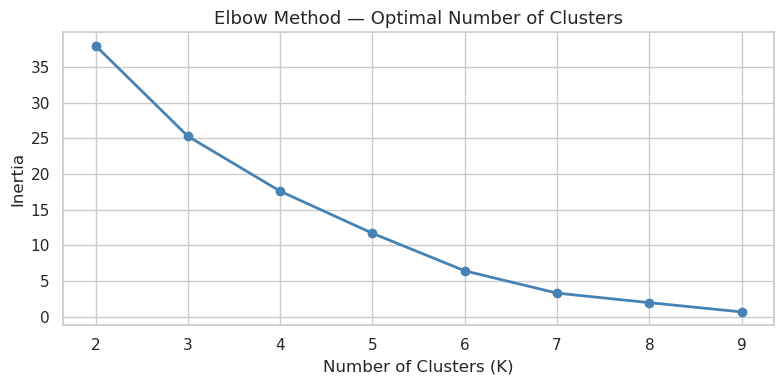

In [12]:
# --- 4C.2 Elbow Method: Find Optimal K ---

scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(country_profile)

inertias = []
K_range = range(2, min(10, len(country_profile)))

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'o-', color='steelblue', linewidth=2)
plt.title('Elbow Method — Optimal Number of Clusters', fontsize=13)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.grid(True)
plt.tight_layout()
plt.savefig('../outputs/figures/kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# --- 4C.3 Fit Final K-Means (K=3) ---

OPTIMAL_K = 3
CLUSTER_LABELS = {
    0: '🟡 Moderate Risk',
    1: '🔴 High Stress',
    2: '🟢 Stable'
}

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
country_profile['Cluster'] = kmeans.fit_predict(X_cluster)
country_profile['Cluster_Label'] = country_profile['Cluster'].map(CLUSTER_LABELS)

# Show cluster assignments
print('\n=== Country Cluster Assignments ===')
for label in CLUSTER_LABELS.values():
    countries_in_cluster = country_profile[country_profile['Cluster_Label'] == label].index.tolist()
    print(f'\n{label} ({len(countries_in_cluster)} countries):')
    print(', '.join(countries_in_cluster))


=== Country Cluster Assignments ===

🟡 Moderate Risk (2 countries):
South Africa, Tanzania

🔴 High Stress (7 countries):
Egypt, Ethiopia, Ghana, Ivory Coast, Kenya, Rwanda, Togo

🟢 Stable (1 countries):
Nigeria


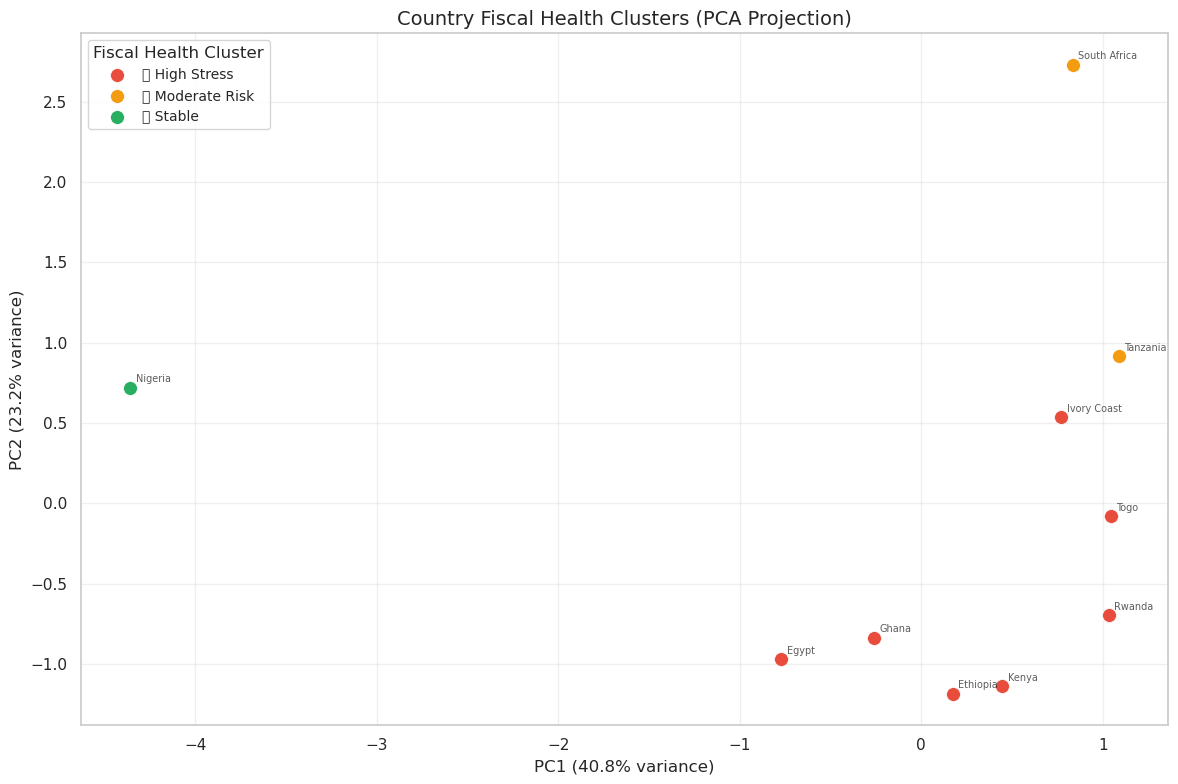


Total variance explained by 2 PCs: 64.0%


In [14]:
# --- 4C.4 Visualize Clusters with PCA ---

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)
explained = pca.explained_variance_ratio_

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'], index=country_profile.index)
pca_df['Cluster_Label'] = country_profile['Cluster_Label'].values

palette = {
    '🔴 High Stress': '#e74c3c',
    '🟡 Moderate Risk': '#f39c12',
    '🟢 Stable': '#27ae60'
}

plt.figure(figsize=(12, 8))
for label, color in palette.items():
    mask = pca_df['Cluster_Label'] == label
    plt.scatter(
        pca_df.loc[mask, 'PC1'],
        pca_df.loc[mask, 'PC2'],
        c=color, label=label, s=100, edgecolors='white', linewidths=0.5
    )
    for country in pca_df[mask].index:
        plt.annotate(
            country,
            (pca_df.loc[country, 'PC1'], pca_df.loc[country, 'PC2']),
            fontsize=7, alpha=0.75,
            xytext=(4, 4), textcoords='offset points'
        )

plt.title('Country Fiscal Health Clusters (PCA Projection)', fontsize=14)
plt.xlabel(f'PC1 ({explained[0]:.1%} variance)')
plt.ylabel(f'PC2 ({explained[1]:.1%} variance)')
plt.legend(title='Fiscal Health Cluster', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/country_clusters_pca.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTotal variance explained by 2 PCs: {sum(explained):.1%}')

## **Phase 4D — Policy Recommendation Framework**

Based on the cluster each country falls into, we generate tailored **policy recommendations** aligned with the UN SDGs.

In [15]:
# --- 4D.1 Policy Recommendation Engine ---

POLICY_FRAMEWORK = {
    '🔴 High Stress': {
        'Priority SDGs': ['SDG 1 (No Poverty)', 'SDG 8 (Decent Work)', 'SDG 10 (Reduced Inequalities)'],
        'Fiscal Actions': [
            'Urgently widen tax base and combat revenue leakages',
            'Restructure government debt to reduce debt servicing burden',
            'Implement strict expenditure rationalization — cut non-productive spending',
            'Attract concessional financing from multilateral institutions (IMF, World Bank)',
        ],
        'Economic Actions': [
            'Tighten monetary policy to control inflation above 10%',
            'Diversify export base to reduce forex vulnerability',
            'Invest in social safety nets to protect vulnerable populations',
        ]
    },
    '🟡 Moderate Risk': {
        'Priority SDGs': ['SDG 8 (Decent Work)', 'SDG 9 (Industry & Innovation)', 'SDG 17 (Partnerships)'],
        'Fiscal Actions': [
            'Strengthen VAT/tax collection efficiency',
            'Gradually reduce deficit below 3% of GDP',
            'Increase capital expenditure as % of total budget',
        ],
        'Economic Actions': [
            'Invest in infrastructure to unlock private sector growth',
            'Develop domestic capital markets to reduce external debt reliance',
            'Improve ease of doing business rankings',
        ]
    },
    '🟢 Stable': {
        'Priority SDGs': ['SDG 4 (Quality Education)', 'SDG 3 (Good Health)', 'SDG 13 (Climate Action)'],
        'Fiscal Actions': [
            'Sustain fiscal discipline — maintain debt below 60% GDP',
            'Build fiscal buffers (sovereign wealth / stabilization funds)',
            'Increase health and education expenditure as % of GDP',
        ],
        'Economic Actions': [
            'Leverage stable macro environment to attract FDI',
            'Invest in green energy transition and climate resilience',
            'Develop regional trade integration with neighboring economies',
        ]
    }
}

print('=== POLICY RECOMMENDATION FRAMEWORK ===')
print('=' * 60)

for cluster_label, policy in POLICY_FRAMEWORK.items():
    countries_in = country_profile[country_profile['Cluster_Label'] == cluster_label].index.tolist()
    print(f'\n{cluster_label}')
    print(f'Countries: {", ".join(countries_in[:10])} {"..." if len(countries_in) > 10 else ""}')
    print(f'Priority SDGs: {", ".join(policy["Priority SDGs"])}')
    print('\nFiscal Actions:')
    for action in policy['Fiscal Actions']:
        print(f'  ▸ {action}')
    print('\nEconomic Actions:')
    for action in policy['Economic Actions']:
        print(f'  ▸ {action}')
    print('-' * 60)

=== POLICY RECOMMENDATION FRAMEWORK ===

🔴 High Stress
Countries: Egypt, Ethiopia, Ghana, Ivory Coast, Kenya, Rwanda, Togo 
Priority SDGs: SDG 1 (No Poverty), SDG 8 (Decent Work), SDG 10 (Reduced Inequalities)

Fiscal Actions:
  ▸ Urgently widen tax base and combat revenue leakages
  ▸ Restructure government debt to reduce debt servicing burden
  ▸ Implement strict expenditure rationalization — cut non-productive spending
  ▸ Attract concessional financing from multilateral institutions (IMF, World Bank)

Economic Actions:
  ▸ Tighten monetary policy to control inflation above 10%
  ▸ Diversify export base to reduce forex vulnerability
  ▸ Invest in social safety nets to protect vulnerable populations
------------------------------------------------------------

🟡 Moderate Risk
Countries: South Africa, Tanzania 
Priority SDGs: SDG 8 (Decent Work), SDG 9 (Industry & Innovation), SDG 17 (Partnerships)

Fiscal Actions:
  ▸ Strengthen VAT/tax collection efficiency
  ▸ Gradually reduce defi

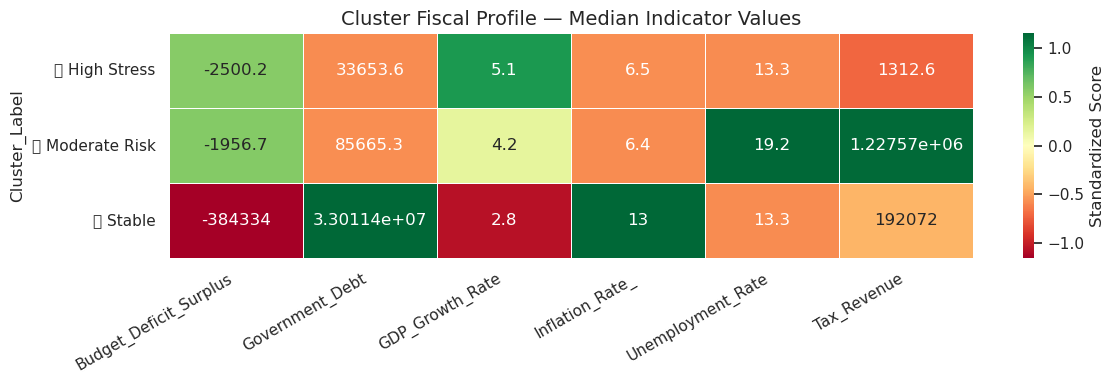


✅ All Phase 4 outputs saved to outputs/figures/


In [16]:
# --- 4D.2 Cluster Profile Summary Heatmap ---

cluster_summary = (
    country_profile
    .groupby('Cluster_Label')[available_cluster_features]
    .median()
)

# Normalize for heatmap readability
cluster_summary_norm = (cluster_summary - cluster_summary.mean()) / cluster_summary.std()

plt.figure(figsize=(12, 4))
sns.heatmap(
    cluster_summary_norm,
    annot=cluster_summary.round(1),
    fmt='g',
    cmap='RdYlGn',
    linewidths=0.5,
    cbar_kws={'label': 'Standardized Score'}
)
plt.title('Cluster Fiscal Profile — Median Indicator Values', fontsize=14)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../outputs/figures/cluster_profile_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n✅ All Phase 4 outputs saved to outputs/figures/')

## Summary

| Track | Model | Output |
|-------|-------|--------|
| 4A | Prophet | 5-year GDP growth forecasts per country |
| 4B | XGBoost | Fiscal risk classifier + feature importances |
| 4C | K-Means | Country clusters by fiscal health profile |
| 4D | Rule-based | SDG-aligned policy recommendations per cluster |

### Key Takeaways
- **High Stress** countries (mainly West African) need urgent fiscal consolidation and external support
- **Moderate Risk** countries need structural reforms to prevent deterioration
- **Stable** countries should use fiscal headroom to invest in human capital and climate resilience
- The **XGBoost classifier** identifies `Revenue`, `Expenditure`, and `GDP Growth Rate` as the strongest fiscal risk predictors